# Fintech Churn Intelligence: Customer Churn Prediction & Risk Scoring

**Objective**
Build, tune, and validate a machine learning system to predict customer churn, explain *why* customers churn, and generate a defensible, business-ready risk score for CRM/retention targeting.

**Dataset:** `Churn_Modelling.csv` — 10,000 bank customers, 14 columns, binary target `Exited` (1 = churned).

**Notebook Structure**
1. Setup & Imports
2. Data Loading & Quality Check
3. Exploratory Data Analysis
4. Preprocessing & Feature Encoding
5. Train/Test Split & Scaling
6. Baseline Models (Logistic Regression, Random Forest)
7. Handling Class Imbalance (`class_weight`)
8. Hyperparameter Tuning (`GridSearchCV`)
9. Model Evaluation Suite — Classification Report, Confusion Matrix, ROC Curve/AUC, Precision-Recall Curve
10. Decision Threshold Optimization
11. Customer Risk Scoring
12. Risk Score Validation (lift / decile analysis)
13. Model Explainability (SHAP)
14. Business Summary & Deliverables

**Business Goal:** Enable the CRM and retention teams to proactively identify high-risk customers, understand the top drivers of churn, and launch targeted retention campaigns before churn occurs.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)

import shap

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 42

print("Libraries Loaded Successfully")


Libraries Loaded Successfully


## 1. Data Loading & Quality Check

We drop identifier columns (`RowNumber`, `CustomerId`, `Surname`) since they carry no predictive signal and risk leaking noise / overfitting into tree-based models. We also confirm there are no missing values before modeling.

In [32]:
df = pd.read_csv("/Users/sumitkumargupta/Desktop/1_Project/01_Data/Churn_Modelling.csv")

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum(), "total missing cells")
print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

df.head()


Shape: (10000, 14)

Missing values:
 0 total missing cells

Duplicate rows: 0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Exploratory Data Analysis

Before modeling, we check the target class balance (this directly motivates the class-weighting step later) and look at how churn varies across a few key segments.

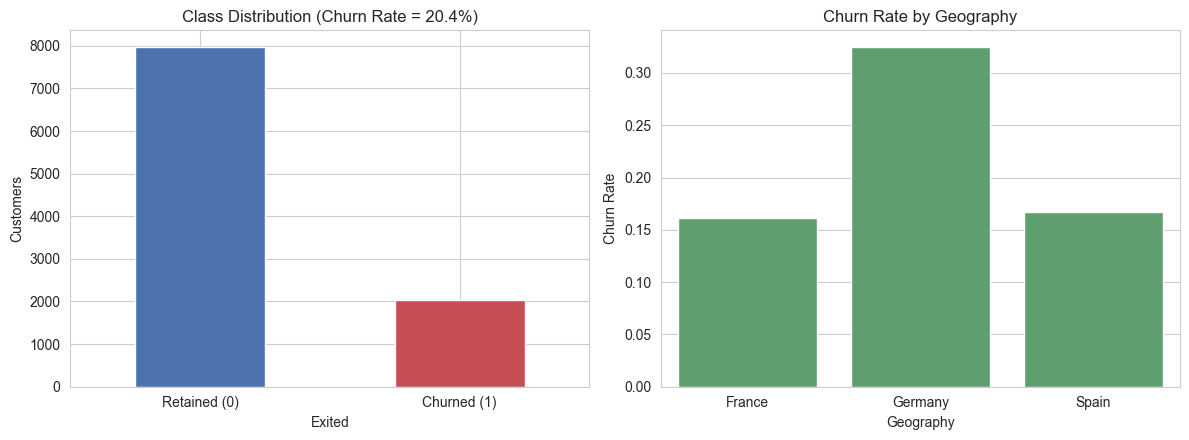

Overall churn rate: 20.37%
This is a moderately imbalanced classification problem (~80/20 split),
which is why class weighting and threshold tuning matter later in this notebook.


In [33]:
churn_rate = df["Exited"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df["Exited"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"]
)
axes[0].set_title(f"Class Distribution (Churn Rate = {churn_rate:.1%})")
axes[0].set_xticklabels(["Retained (0)", "Churned (1)"], rotation=0)
axes[0].set_ylabel("Customers")

sns.barplot(
    data=df.groupby("Geography")["Exited"].mean().reset_index(),
    x="Geography", y="Exited", ax=axes[1], color="#55A868"
)
axes[1].set_title("Churn Rate by Geography")
axes[1].set_ylabel("Churn Rate")

plt.tight_layout()
plt.show()

print(f"Overall churn rate: {churn_rate:.2%}")
print("This is a moderately imbalanced classification problem (~80/20 split),")
print("which is why class weighting and threshold tuning matter later in this notebook.")


## 3. Preprocessing & Feature Encoding

**Fix vs. original notebook:** the original used `LabelEncoder` on both `Gender` and `Geography`. `Gender` is binary, so label encoding is fine — but `Geography` has 3 unrelated categories (France/Germany/Spain), and label-encoding it implies a false ordinal relationship (e.g. Spain > Germany > France) that linear models will pick up incorrectly. We use **one-hot encoding** for `Geography` instead.

In [34]:
df_model = df.copy()

df_model["Gender"] = df_model["Gender"].map({"Male": 1, "Female": 0})

df_model = pd.get_dummies(df_model, columns=["Geography"], drop_first=True)

X = df_model.drop("Exited", axis=1)
y = df_model["Exited"]

print("Final feature set:", list(X.columns))
X.head()


Final feature set: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True


## 4. Train/Test Split & Scaling

We stratify the split on `y` to preserve the ~20% churn rate in both sets. Scaling is fit **only on the training data** and applied to test data to avoid data leakage. Scaling is required for Logistic Regression (distance/coefficient-based) but not for Random Forest (tree splits are scale-invariant) — we keep both versions.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train churn rate:", y_train.mean().round(4), "| Test churn rate:", y_test.mean().round(4))


Train shape: (8000, 11)
Test shape : (2000, 11)
Train churn rate: 0.2037 | Test churn rate: 0.2035


## 5. Baseline Models

We fit a Logistic Regression (interpretable, linear baseline) and a Random Forest (non-linear, typically stronger) as our two candidate model families.

In [36]:
lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_base.fit(X_train_sc, y_train)

lr_base_prob = lr_base.predict_proba(X_test_sc)[:, 1]
lr_base_pred = lr_base.predict(X_test_sc)

print("Logistic Regression (baseline)")
print("Accuracy:", round(accuracy_score(y_test, lr_base_pred), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, lr_base_prob), 4))


Logistic Regression (baseline)
Accuracy: 0.808
ROC-AUC : 0.7748


In [37]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_base.fit(X_train, y_train)

rf_base_prob = rf_base.predict_proba(X_test)[:, 1]
rf_base_pred = rf_base.predict(X_test)

print("Random Forest (baseline)")
print("Accuracy:", round(accuracy_score(y_test, rf_base_pred), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, rf_base_prob), 4))


Random Forest (baseline)
Accuracy: 0.862
ROC-AUC : 0.8554


## 6. Handling Class Imbalance — `class_weight`

With ~80% retained / ~20% churned, an unweighted model can achieve high accuracy simply by predicting "retained" often, while missing the churners we actually care about. We refit both models with `class_weight="balanced"`, which reweights the loss function inversely proportional to class frequency — pushing the model to pay more attention to the minority (churn) class. This typically trades a little accuracy for meaningfully better recall on churners, which is the right trade-off for a retention use case (a missed churner costs more than a false alarm).

In [38]:
lr_bal = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
lr_bal.fit(X_train_sc, y_train)
lr_bal_prob = lr_bal.predict_proba(X_test_sc)[:, 1]
lr_bal_pred = lr_bal.predict(X_test_sc)

rf_bal = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE)
rf_bal.fit(X_train, y_train)
rf_bal_prob = rf_bal.predict_proba(X_test)[:, 1]
rf_bal_pred = rf_bal.predict(X_test)

print("Effect of class_weight='balanced' (Recall on churn class):")
print(f"  Logistic Regression -> baseline recall: {recall_score(y_test, lr_base_pred):.3f} | balanced recall: {recall_score(y_test, lr_bal_pred):.3f}")
print(f"  Random Forest       -> baseline recall: {recall_score(y_test, rf_base_pred):.3f} | balanced recall: {recall_score(y_test, rf_bal_pred):.3f}")


Effect of class_weight='balanced' (Recall on churn class):
  Logistic Regression -> baseline recall: 0.187 | balanced recall: 0.700
  Random Forest       -> baseline recall: 0.459 | balanced recall: 0.585


## 7. Hyperparameter Tuning — `GridSearchCV`

We tune the Random Forest (our stronger baseline) using 5-fold stratified cross-validation, optimizing for **ROC-AUC** rather than accuracy, since AUC is threshold-independent and more meaningful under class imbalance.

In [39]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [6, 10, None],
    "min_samples_leaf": [1, 5, 10],
    "class_weight": ["balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC :", round(grid.best_score_, 4))

best_rf = grid.best_estimator_
best_prob = best_rf.predict_proba(X_test)[:, 1]
best_pred = best_rf.predict(X_test)

print("\nTuned Random Forest — Test set ROC-AUC:", round(roc_auc_score(y_test, best_prob), 4))


Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV ROC-AUC : 0.8594

Tuned Random Forest — Test set ROC-AUC: 0.8636


## 8. Model Comparison Summary

Bringing all model variants together before committing to a final model for the evaluation suite below.

In [40]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (baseline)",
        "Random Forest (baseline)",
        "Logistic Regression (balanced)",
        "Random Forest (balanced)",
        "Random Forest (tuned, balanced)"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_base_pred),
        accuracy_score(y_test, rf_base_pred),
        accuracy_score(y_test, lr_bal_pred),
        accuracy_score(y_test, rf_bal_pred),
        accuracy_score(y_test, best_pred),
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, lr_base_prob),
        roc_auc_score(y_test, rf_base_prob),
        roc_auc_score(y_test, lr_bal_prob),
        roc_auc_score(y_test, rf_bal_prob),
        roc_auc_score(y_test, best_prob),
    ],
    "Recall_Churn": [
        recall_score(y_test, lr_base_pred),
        recall_score(y_test, rf_base_pred),
        recall_score(y_test, lr_bal_pred),
        recall_score(y_test, rf_bal_pred),
        recall_score(y_test, best_pred),
    ]
})

comparison = comparison.round(4)
comparison


,Model,Accuracy,ROC_AUC,Recall_Churn
0,Logistic Regression (baseline),0.8080,0.7748,0.1867
1,Random Forest (baseline),0.8620,0.8554,0.4595
2,Logistic Regression (balanced),0.7135,0.7771,0.7002
3,Random Forest (balanced),0.8450,0.8547,0.5848
4,"Random Forest (tuned, balanced)",0.8105,0.8636,0.7371


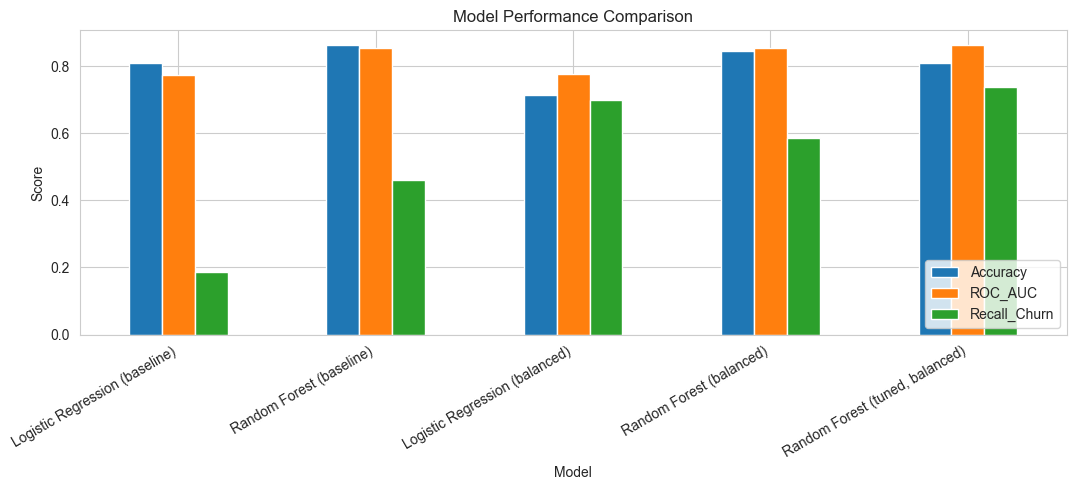

Final model selected: Tuned Random Forest (balanced class weights)


In [41]:
comparison.set_index("Model")[["Accuracy", "ROC_AUC", "Recall_Churn"]].plot(
    kind="bar", figsize=(11, 5)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

FINAL_MODEL = best_rf
FINAL_PROB = best_prob
FINAL_PRED = best_pred
print("Final model selected: Tuned Random Forest (balanced class weights)")


## 9. Model Evaluation Suite (Final Model)

### 9.1 Classification Report
Gives per-class precision, recall, and F1 — critical because overall accuracy hides how well we actually detect churners.

In [42]:
print(classification_report(y_test, FINAL_PRED, target_names=["Retained (0)", "Churned (1)"]))


              precision    recall  f1-score   support

Retained (0)       0.93      0.83      0.87      1593
 Churned (1)       0.52      0.74      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



### 9.2 Confusion Matrix

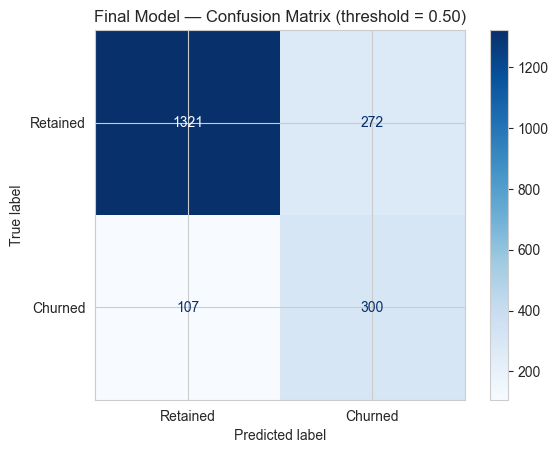

True Negatives: 1321 | False Positives: 272 | False Negatives: 107 | True Positives: 300


In [43]:
cm = confusion_matrix(y_test, FINAL_PRED)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Retained", "Churned"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Final Model — Confusion Matrix (threshold = 0.50)")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn} | False Positives: {fp} | False Negatives: {fn} | True Positives: {tp}")


### 9.3 ROC Curve & ROC-AUC
ROC-AUC measures how well the model ranks churners above non-churners across *all* thresholds, independent of any single cutoff.

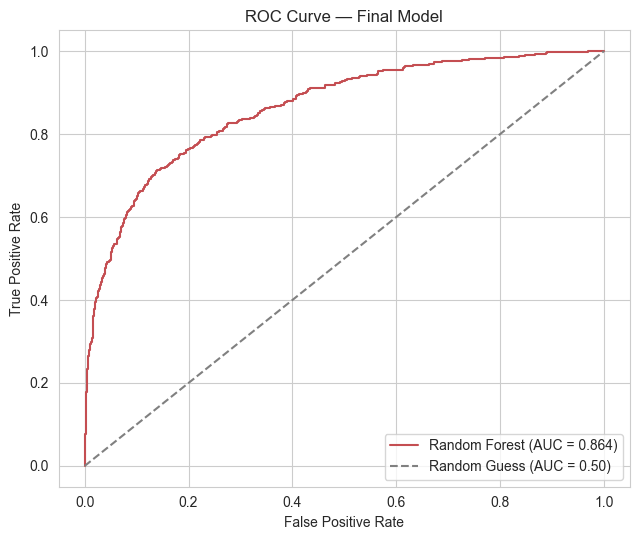

ROC-AUC: 0.8636


In [44]:
fpr, tpr, roc_thresholds = roc_curve(y_test, FINAL_PROB)
auc_score = roc_auc_score(y_test, FINAL_PROB)

plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.3f})", color="#C44E52")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")


### 9.4 Precision-Recall Curve
More informative than ROC when the positive class (churn) is the minority — shows the real precision/recall trade-off at each threshold, summarized by Average Precision (AP).

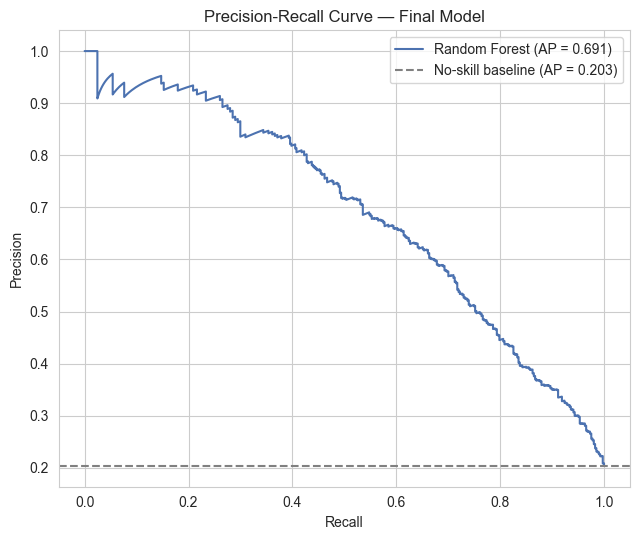

Average Precision (AP): 0.6910


In [45]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, FINAL_PROB)
ap_score = average_precision_score(y_test, FINAL_PROB)

plt.figure(figsize=(6.5, 5.5))
plt.plot(recall, precision, color="#4C72B0", label=f"Random Forest (AP = {ap_score:.3f})")
baseline_precision = y_test.mean()
plt.axhline(baseline_precision, linestyle="--", color="gray",
            label=f"No-skill baseline (AP = {baseline_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Final Model")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"Average Precision (AP): {ap_score:.4f}")


## 10. Decision Threshold Optimization

The default 0.50 cutoff is arbitrary. For a retention use case, missing a churner (false negative) is usually costlier than a wasted retention offer (false positive). We scan thresholds and compare precision, recall, and F1 to pick a threshold aligned with that business trade-off, rather than defaulting to 0.50.

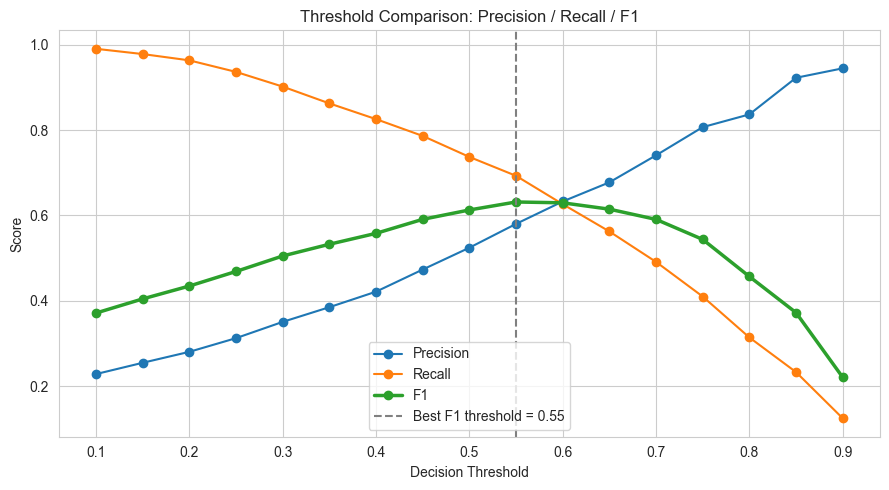

 Threshold  Precision  Recall    F1
      0.10      0.229   0.990 0.372
      0.15      0.255   0.978 0.405
      0.20      0.281   0.963 0.435
      0.25      0.313   0.936 0.469
      0.30      0.351   0.902 0.505
      0.35      0.385   0.862 0.533
      0.40      0.422   0.826 0.558
      0.45      0.473   0.786 0.591
      0.50      0.524   0.737 0.613
      0.55      0.580   0.693 0.632
      0.60      0.633   0.627 0.630
      0.65      0.678   0.563 0.615
      0.70      0.741   0.491 0.591
      0.75      0.807   0.410 0.544
      0.80      0.837   0.314 0.457
      0.85      0.922   0.233 0.373
      0.90      0.944   0.125 0.221

Threshold that maximizes F1: 0.55 (Precision=0.580, Recall=0.693)


In [46]:
thresholds_to_test = np.arange(0.10, 0.91, 0.05)

threshold_results = []
for t in thresholds_to_test:
    preds_t = (FINAL_PROB >= t).astype(int)
    threshold_results.append({
        "Threshold": round(t, 2),
        "Precision": precision_score(y_test, preds_t, zero_division=0),
        "Recall": recall_score(y_test, preds_t, zero_division=0),
        "F1": f1_score(y_test, preds_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
best_f1_row = threshold_df.loc[threshold_df["F1"].idxmax()]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
ax.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
ax.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1", linewidth=2.5)
ax.axvline(best_f1_row["Threshold"], linestyle="--", color="gray",
           label=f"Best F1 threshold = {best_f1_row['Threshold']}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Comparison: Precision / Recall / F1")
ax.legend()
plt.tight_layout()
plt.show()

print(threshold_df.round(3).to_string(index=False))
print(f"\nThreshold that maximizes F1: {best_f1_row['Threshold']} "
      f"(Precision={best_f1_row['Precision']:.3f}, Recall={best_f1_row['Recall']:.3f})")

CHOSEN_THRESHOLD = float(best_f1_row["Threshold"])


## 11. Customer Risk Scoring

We convert model probabilities into a 0-100 risk score and bucket customers into Low / Medium / High risk tiers, which is a format retention/CRM teams can act on directly (rather than raw probabilities).

In [47]:
risk_df = X_test.copy()
risk_df["Actual_Churn"] = y_test.values
risk_df["Churn_Probability"] = FINAL_PROB
risk_df["Risk_Score"] = (FINAL_PROB * 100).round(1)

def risk_tier(p):
    if p >= 0.60:
        return "High"
    elif p >= 0.30:
        return "Medium"
    else:
        return "Low"

risk_df["Risk_Tier"] = risk_df["Churn_Probability"].apply(risk_tier)

tier_summary = risk_df.groupby("Risk_Tier").agg(
    Customers=("Risk_Tier", "count"),
    Actual_Churn_Rate=("Actual_Churn", "mean")
).reindex(["High", "Medium", "Low"])

tier_summary["Actual_Churn_Rate"] = tier_summary["Actual_Churn_Rate"].round(3)
tier_summary


,Customers,Actual_Churn_Rate
Risk_Tier,,
High,403,0.633
Medium,643,0.174
Low,954,0.042


## 12. Risk Score Validation (Decile / Lift Analysis)

A risk score is only trustworthy if higher scores actually correspond to higher real-world churn. We validate this by splitting customers into deciles by predicted probability and checking that actual churn rate rises monotonically (or close to it) with predicted risk. This is the standard way to defend a risk score to stakeholders.

        Customers  Avg_Predicted_Prob  Actual_Churn_Rate  Lift_vs_Overall
Decile                                                                   
10            200               0.855              0.820             4.03
9             200               0.677              0.450             2.21
8             200               0.543              0.260             1.28
7             200               0.440              0.150             0.74
6             200               0.356              0.120             0.59
5             200               0.285              0.105             0.52
4             200               0.228              0.060             0.29
3             200               0.169              0.030             0.15
2             200               0.113              0.025             0.12
1             200               0.061              0.015             0.07


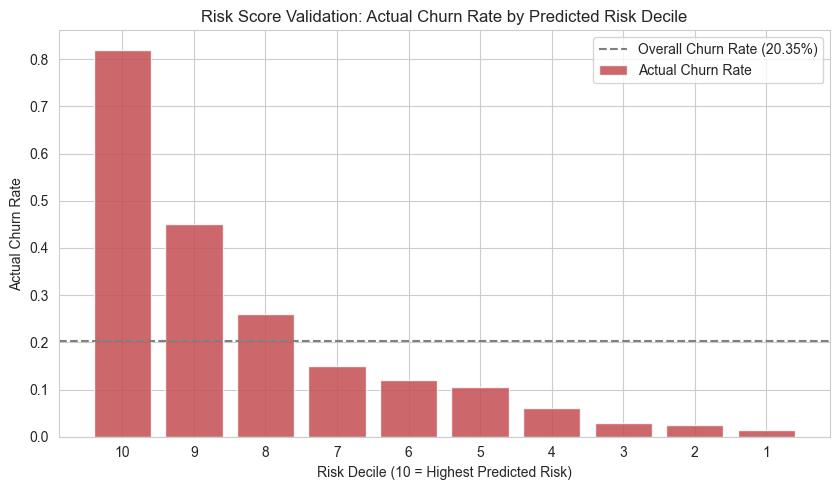


Top decile is 4.03x more likely to churn than an average customer,
confirming the risk score meaningfully separates high-risk from low-risk customers.


In [48]:
risk_df["Decile"] = pd.qcut(risk_df["Churn_Probability"], 10, labels=False, duplicates="drop") + 1

decile_val = risk_df.groupby("Decile").agg(
    Customers=("Decile", "count"),
    Avg_Predicted_Prob=("Churn_Probability", "mean"),
    Actual_Churn_Rate=("Actual_Churn", "mean")
).sort_index(ascending=False)

decile_val["Avg_Predicted_Prob"] = decile_val["Avg_Predicted_Prob"].round(3)
decile_val["Actual_Churn_Rate"] = decile_val["Actual_Churn_Rate"].round(3)

overall_rate = y_test.mean()
decile_val["Lift_vs_Overall"] = (decile_val["Actual_Churn_Rate"] / overall_rate).round(2)

print(decile_val.to_string())

plt.figure(figsize=(8.5, 5))
plt.bar(decile_val.index.astype(str), decile_val["Actual_Churn_Rate"], color="#C44E52", alpha=0.85, label="Actual Churn Rate")
plt.axhline(overall_rate, linestyle="--", color="gray", label=f"Overall Churn Rate ({overall_rate:.2%})")
plt.xlabel("Risk Decile (10 = Highest Predicted Risk)")
plt.ylabel("Actual Churn Rate")
plt.title("Risk Score Validation: Actual Churn Rate by Predicted Risk Decile")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nTop decile is {decile_val['Lift_vs_Overall'].iloc[0]:.2f}x more likely to churn than an average customer,")
print("confirming the risk score meaningfully separates high-risk from low-risk customers.")


## 13. Model Explainability — SHAP

SHAP (SHapley Additive exPlanations) values quantify each feature's contribution to individual predictions, letting us explain *why* the model flagged a customer as high-risk — essential for stakeholder trust and for going beyond simple feature importance rankings.

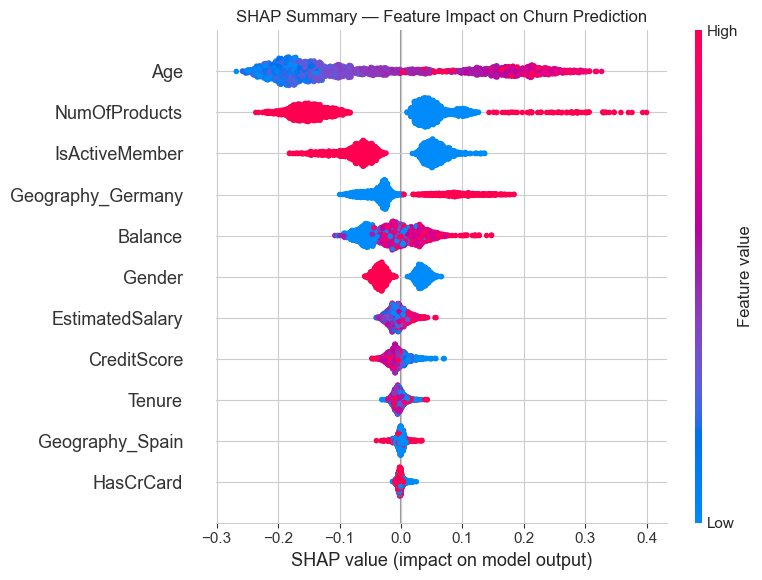

In [49]:
explainer = shap.TreeExplainer(FINAL_MODEL)
shap_values = explainer.shap_values(X_test)

# For binary classifiers, shap_values may be returned as a list [class0, class1] or a single 2D/3D array depending on version
if isinstance(shap_values, list):
    shap_vals_churn = shap_values[1]
elif shap_values.ndim == 3:
    shap_vals_churn = shap_values[:, :, 1]
else:
    shap_vals_churn = shap_values

shap.summary_plot(shap_vals_churn, X_test, show=False)
plt.title("SHAP Summary — Feature Impact on Churn Prediction")
plt.tight_layout()
plt.show()


**Global feature impact (bar chart)** — average absolute SHAP value per feature, i.e. overall importance ranked by actual contribution to predictions rather than just split-based Gini importance.

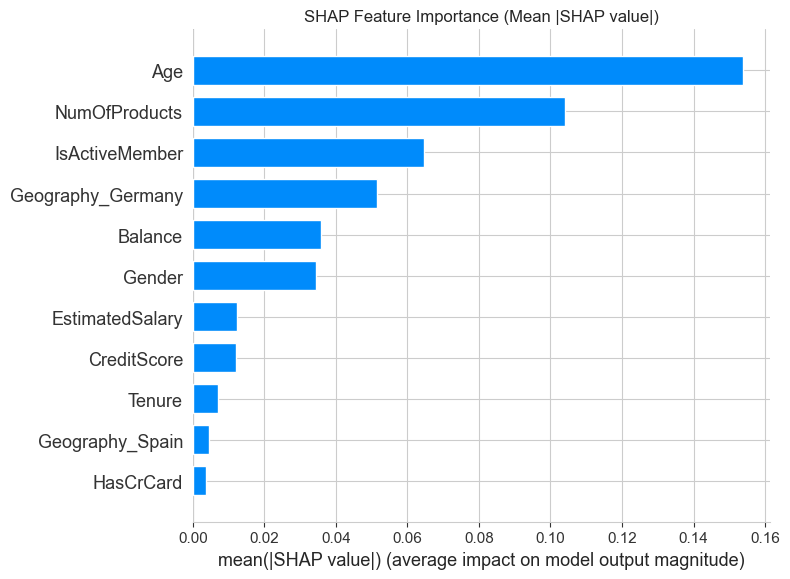

In [50]:
shap.summary_plot(shap_vals_churn, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.show()


**Local explanation example** — a single high-risk customer, showing exactly which features pushed their predicted churn probability up or down. This is the kind of explanation a retention agent could act on directly.

Example customer — predicted churn probability: 97.10%
                        5942
CreditScore              517
Gender                     1
Age                       53
Tenure                     0
Balance            109172.88
NumOfProducts              1
HasCrCard                  1
IsActiveMember             0
EstimatedSalary      54676.1
Geography_Germany       True
Geography_Spain        False


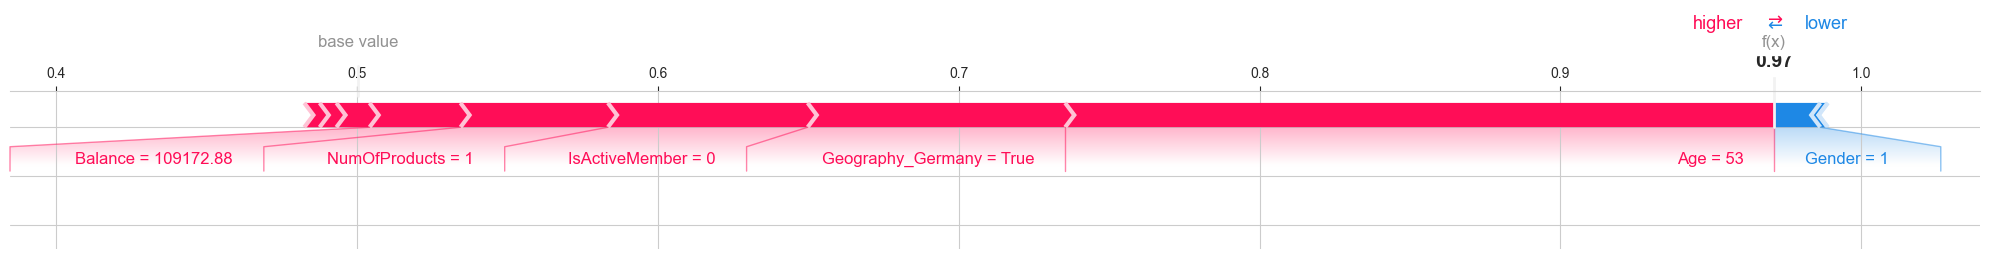

In [51]:
highest_risk_idx = np.argmax(FINAL_PROB)

sample_customer = X_test.iloc[[highest_risk_idx]]
sample_prob = FINAL_PROB[highest_risk_idx]

print(f"Example customer — predicted churn probability: {sample_prob:.2%}")
print(sample_customer.T)

shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) and np.ndim(explainer.expected_value) > 0 else explainer.expected_value,
    shap_vals_churn[highest_risk_idx],
    sample_customer,
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.show()


## 14. Feature Importance — Model-Native vs. SHAP

We also keep the Random Forest's native (Gini-based) feature importance for comparison. SHAP and Gini importance usually broadly agree, but SHAP is more reliable when features are correlated or on different scales.

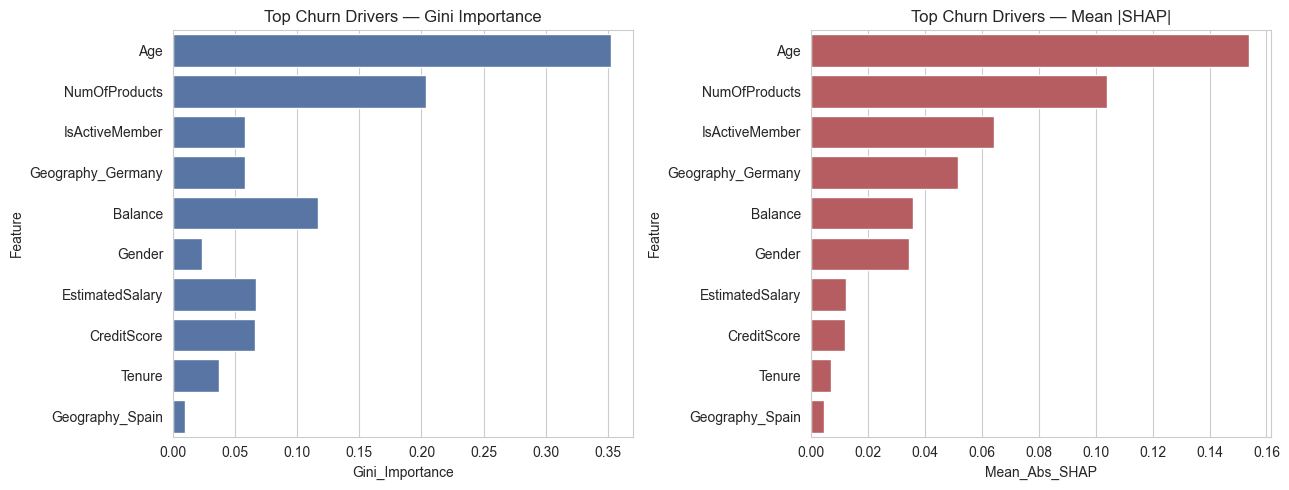

,Feature,Gini_Importance,Mean_Abs_SHAP
2,Age,0.3525,0.1538
5,NumOfProducts,0.2034,0.1041
7,IsActiveMember,0.0584,0.0645
9,Geography_Germany,0.0576,0.0515
4,Balance,0.1165,0.0358
1,Gender,0.0238,0.0345
8,EstimatedSalary,0.0668,0.0124
0,CreditScore,0.0663,0.0122
3,Tenure,0.0372,0.0070
10,Geography_Spain,0.0096,0.0046


In [52]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Gini_Importance": FINAL_MODEL.feature_importances_,
    "Mean_Abs_SHAP": np.abs(shap_vals_churn).mean(axis=0)
}).sort_values("Mean_Abs_SHAP", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=importance_df.head(10), x="Gini_Importance", y="Feature", ax=axes[0], color="#4C72B0")
axes[0].set_title("Top Churn Drivers — Gini Importance")

sns.barplot(data=importance_df.head(10), x="Mean_Abs_SHAP", y="Feature", ax=axes[1], color="#C44E52")
axes[1].set_title("Top Churn Drivers — Mean |SHAP|")

plt.tight_layout()
plt.show()

importance_df.round(4)


## 15. Business Summary & Deliverables

In [53]:
at_risk_customers = risk_df[risk_df["Risk_Tier"] == "High"].sort_values(
    "Risk_Score", ascending=False
)

output_cols = ["Risk_Score", "Risk_Tier", "Churn_Probability", "Actual_Churn"]
at_risk_export = at_risk_customers[output_cols].reset_index().rename(columns={"index": "Customer_Index"})
at_risk_export.to_csv("at_risk_customers.csv", index=False)

print("="*60)
print("FINTECH CHURN MODEL — RESULTS SUMMARY")
print("="*60)

print(f"\nFinal Model: Tuned Random Forest (class_weight='balanced')")
print(f"Best Hyperparameters: {grid.best_params_}")
print(f"\nTest Set Performance:")
print(f"  ROC-AUC             : {auc_score:.4f}")
print(f"  Average Precision   : {ap_score:.4f}")
print(f"  Accuracy (@0.50)    : {accuracy_score(y_test, FINAL_PRED):.4f}")
print(f"  Chosen F1 Threshold : {CHOSEN_THRESHOLD}")

print(f"\nTop 5 Churn Drivers (by SHAP):")
for i, row in enumerate(importance_df.head(5).itertuples(), 1):
    print(f"  {i}. {row.Feature}")

print(f"\nRisk Segmentation (test set, n={len(risk_df)}):")
for tier in ["High", "Medium", "Low"]:
    n = (risk_df['Risk_Tier'] == tier).sum()
    rate = risk_df.loc[risk_df['Risk_Tier'] == tier, 'Actual_Churn'].mean()
    print(f"  {tier:<7} tier: {n:>4} customers | actual churn rate: {rate:.1%}")

print(f"\nValidation: top risk decile churns at {decile_val['Lift_vs_Overall'].iloc[0]:.2f}x the base rate,")
print("confirming risk scores are reliable enough to drive targeting decisions.")

print("\nBusiness Recommendations:")
print("  - Prioritize retention outreach for the High risk tier (~{:.0f} customers)".format((risk_df['Risk_Tier']=='High').sum()))
print("  - Investigate top SHAP drivers (e.g. inactivity, product count, age, geography) for root-cause fixes")
print("  - Re-score customers monthly and monitor decile lift to catch model drift")

print("\nOutput Generated: at_risk_customers.csv ({} rows)".format(len(at_risk_export)))


FINTECH CHURN MODEL — RESULTS SUMMARY

Final Model: Tuned Random Forest (class_weight='balanced')
Best Hyperparameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 200}

Test Set Performance:
  ROC-AUC             : 0.8636
  Average Precision   : 0.6910
  Accuracy (@0.50)    : 0.8105
  Chosen F1 Threshold : 0.55

Top 5 Churn Drivers (by SHAP):
  1. Age
  2. NumOfProducts
  3. IsActiveMember
  4. Geography_Germany
  5. Balance

Risk Segmentation (test set, n=2000):
  High    tier:  403 customers | actual churn rate: 63.3%
  Medium  tier:  643 customers | actual churn rate: 17.4%
  Low     tier:  954 customers | actual churn rate: 4.2%

Validation: top risk decile churns at 4.03x the base rate,
confirming risk scores are reliable enough to drive targeting decisions.

Business Recommendations:
  - Prioritize retention outreach for the High risk tier (~403 customers)
  - Investigate top SHAP drivers (e.g. inactivity, product count, age, geography

---
### Interview Talking Points

- **Why class_weight over SMOTE?** Simpler, no synthetic data risk, works natively with both LR and RF, and is easy to justify: it reweights the existing loss function rather than fabricating minority-class rows.
- **Why tune on ROC-AUC, not accuracy?** With ~80/20 class imbalance, a model predicting "no churn" for everyone gets ~80% accuracy while being useless. AUC is threshold-independent and rewards correct *ranking* of risk.
- **Why not just use 0.5 as the threshold?** Business cost of a false negative (losing a customer) vs. false positive (an unnecessary retention offer) is asymmetric — threshold tuning lets the model align with that cost trade-off instead of an arbitrary default.
- **Why SHAP over Gini importance alone?** Gini importance can be biased toward high-cardinality/continuous features and doesn't explain individual predictions. SHAP is theoretically grounded (Shapley values from game theory), consistent, and supports both global and per-customer explanations.
- **Why validate the risk score with deciles?** Because a model can have good AUC yet still produce risk scores that aren't monotonic in practice; decile/lift analysis is the standard way analysts prove a score is usable for targeting before it goes into a CRM.
